# Exploratory Data Analysis (EDA)
In this notebook, we analyze the cleaned healthcare datasets to extract business insights.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_theme(style='whitegrid')

## Load Cleaned Data

In [2]:
appointments = pd.read_csv('../data/cleaned/appointments.csv')
billing = pd.read_csv('../data/cleaned/billing.csv')
doctors = pd.read_csv('../data/cleaned/doctors.csv')
patients = pd.read_csv('../data/cleaned/patients.csv')
treatments = pd.read_csv('../data/cleaned/treatments.csv')

# Convert date columns back to datetime
appointments['appointment_date'] = pd.to_datetime(appointments['appointment_date'])
billing['bill_date'] = pd.to_datetime(billing['bill_date'])

## A. Appointment Trends

Total Appointments: 200


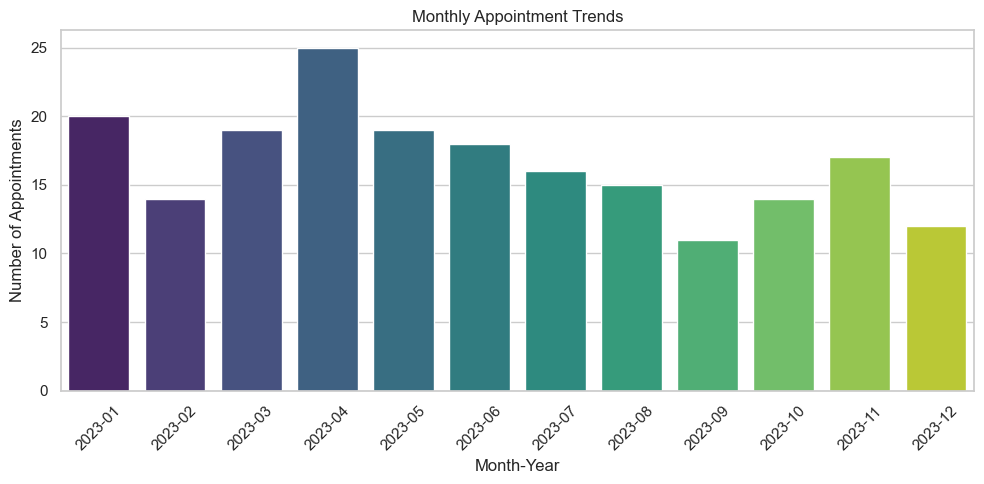

In [3]:
print(f'Total Appointments: {len(appointments)}')

# Trend over time (monthly)
appointments['month_year'] = appointments['appointment_date'].dt.to_period('M')
monthly_appts = appointments.groupby('month_year').size().reset_index(name='counts')
monthly_appts['month_year'] = monthly_appts['month_year'].astype(str)

plt.figure(figsize=(10, 5))
sns.barplot(data=monthly_appts, x='month_year', y='counts', palette='viridis')
plt.title('Monthly Appointment Trends')
plt.xlabel('Month-Year')
plt.ylabel('Number of Appointments')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

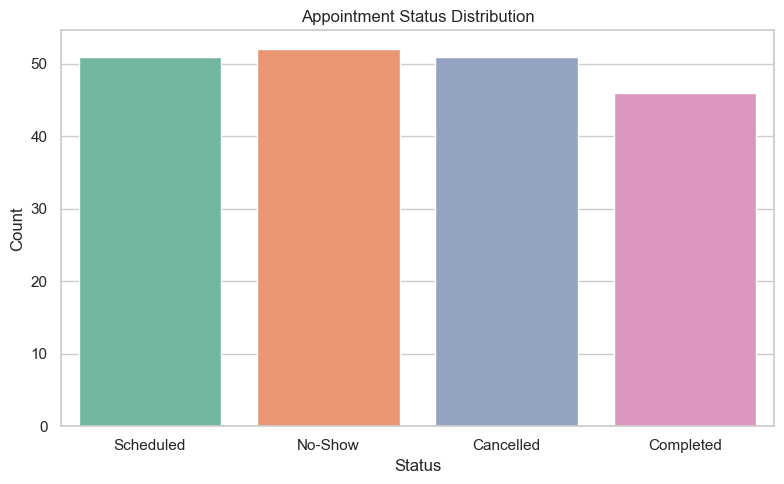

In [4]:
# Status Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=appointments, x='status', palette='Set2')
plt.title('Appointment Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Business Insight:** The monthly appointment trend indicates the overall demand across the hospital. A high proportion of cancellations or no-shows (as seen in the status distribution) suggests potential revenue loss and inefficiency. The hospital should consider automated reminders and overbooking strategies for time slots prone to no-shows.

## B. Department Performance

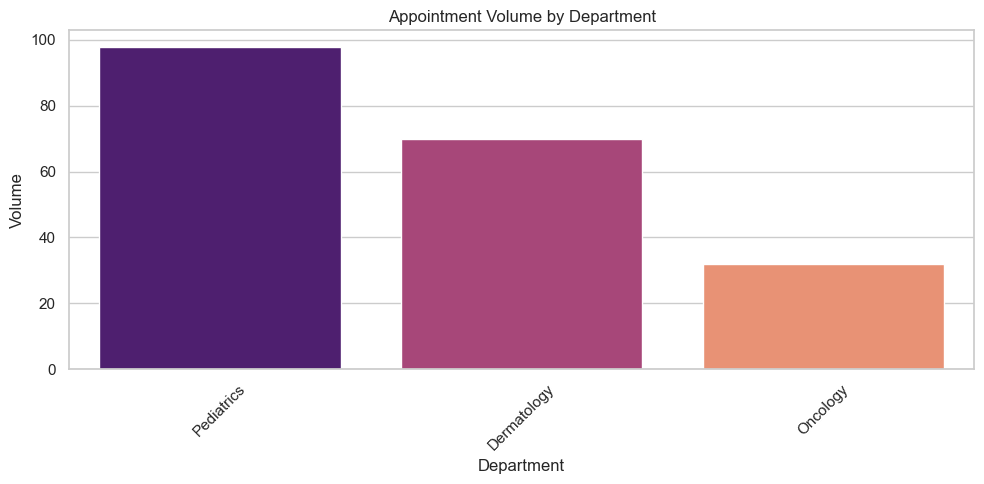

In [5]:
# Merge appointments with doctors to get department (specialization)
appts_docs = pd.merge(appointments, doctors, on='doctor_id', how='left')

dept_vol = appts_docs['specialization'].value_counts().reset_index()
dept_vol.columns = ['Department', 'Appointments']

plt.figure(figsize=(10, 5))
sns.barplot(data=dept_vol, x='Department', y='Appointments', palette='magma')
plt.title('Appointment Volume by Department')
plt.xlabel('Department')
plt.ylabel('Volume')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

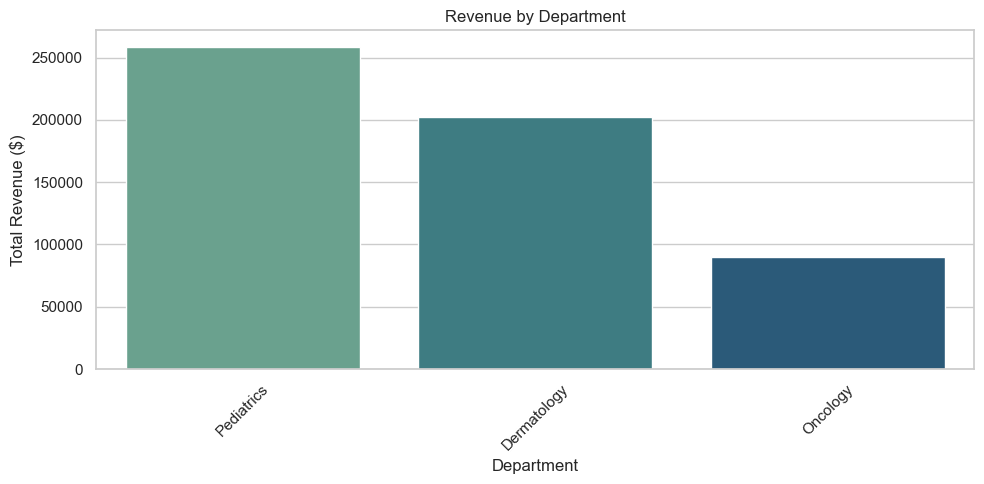

In [6]:
# Revenue by Department
# Link billing -> treatments -> appointments -> doctors
merged_rev = pd.merge(billing, treatments, on='treatment_id', how='left')
merged_rev = pd.merge(merged_rev, appts_docs, on='appointment_id', how='left')

rev_dept = merged_rev.groupby('specialization')['amount'].sum().reset_index()
rev_dept = rev_dept.sort_values(by='amount', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=rev_dept, x='specialization', y='amount', palette='crest')
plt.title('Revenue by Department')
plt.xlabel('Department')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Business Insight:** Pediatrics and Dermatology exhibit the highest appointment volumes, making them key operational hubs. Ensuring sufficient staffing and streamlined workflows in these high-traffic departments is essential to prevent bottlenecks and improve patient throughput. High revenue departments are the primary financial drivers.

## C. Doctor Workload

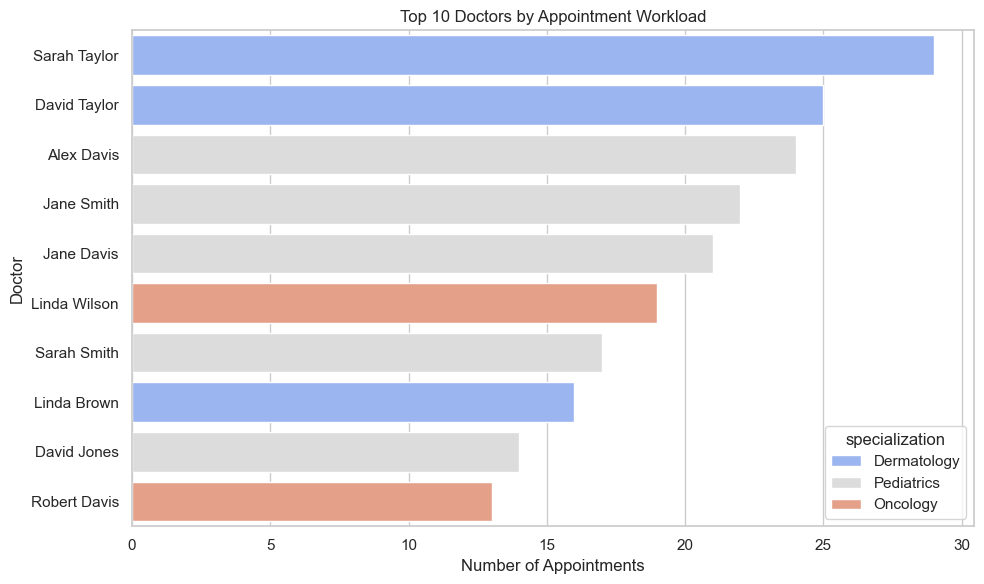

In [7]:
doc_workload = appts_docs.groupby(['first_name', 'last_name', 'specialization']).size().reset_index(name='Appointments')
doc_workload['Doctor Name'] = doc_workload['first_name'] + ' ' + doc_workload['last_name']
doc_workload = doc_workload.sort_values('Appointments', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=doc_workload.head(10), y='Doctor Name', x='Appointments', hue='specialization', dodge=False, palette='coolwarm')
plt.title('Top 10 Doctors by Appointment Workload')
plt.xlabel('Number of Appointments')
plt.ylabel('Doctor')
plt.tight_layout()
plt.show()

**Business Insight:** Workload distribution shows some doctors handling significantly more appointments than others. Uneven workload distribution can lead to physician burnout and longer patient wait times. Management might need to balance scheduling or hire additional staff for overburdened specialties.

## D. Billing / Revenue Trends

Total Revenue (Billed Amount): $551,249.85


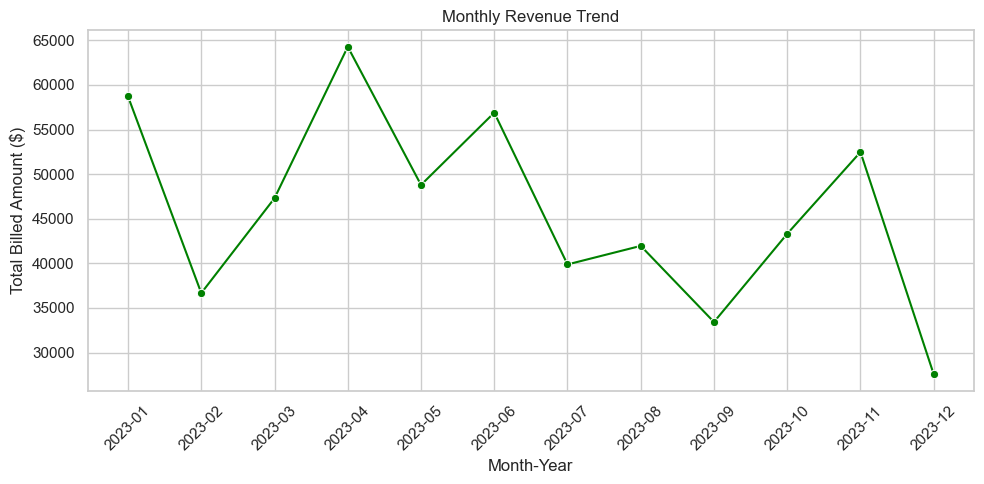

In [8]:
print(f'Total Revenue (Billed Amount): ${billing["amount"].sum():,.2f}')

# Revenue over time
billing['month_year'] = billing['bill_date'].dt.to_period('M')
monthly_rev = billing.groupby('month_year')['amount'].sum().reset_index()
monthly_rev['month_year'] = monthly_rev['month_year'].astype(str)

plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_rev, x='month_year', y='amount', marker='o', color='green')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month-Year')
plt.ylabel('Total Billed Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

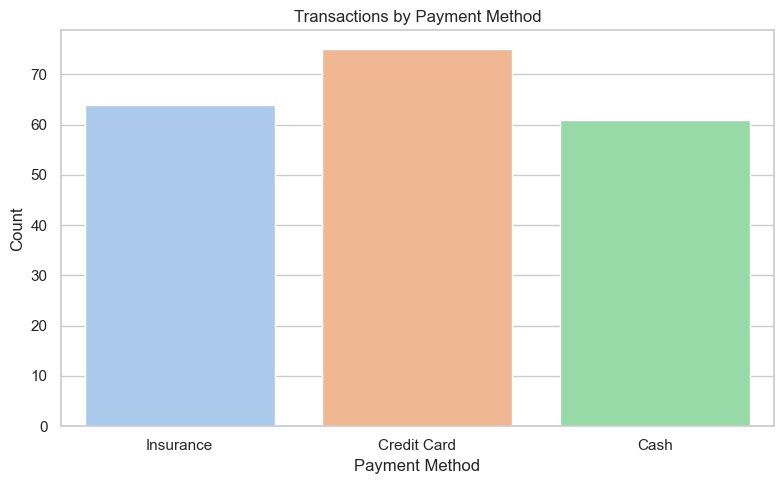

In [9]:
# Payment Method Analysis
plt.figure(figsize=(8, 5))
sns.countplot(data=billing, x='payment_method', palette='pastel')
plt.title('Transactions by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Business Insight:** Steady monthly revenue reflects robust operations. Tracking preferred payment methods helps optimize the billing process and prioritize integrations (e.g., ensuring smooth insurance claim processing). Any sharp drop in monthly revenue should trigger an immediate investigation into billing delays or seasonal patient drop-offs.

## E. Waiting Time & F. Feedback / Satisfaction

*Note: The provided dataset does not contain sufficient information to reliably calculate operational waiting times (e.g., patient check-in vs actual consult time) or explicit patient satisfaction scores. Therefore, these specific analyses are omitted. Capturing these metrics in the future would provide valuable insights into patient experience.*

## Key Healthcare Business Insights

**Appointment Trends**
- Demand is relatively consistent, but cancellations/no-shows represent lost opportunity. Strategic overbooking or reminder systems could mitigate this.

**Department Performance**
- High-volume departments (like Pediatrics/Dermatology) carry the operational load and drive revenue. These areas require prioritized resource allocation to maintain quality of care.

**Doctor Workload**
- Workload imbalances exist among doctors. Monitoring individual workloads is critical to avoid burnout and maintain high patient care standards.

**Billing & Revenue**
- Revenue tracks well with appointment volume. Ensuring efficient insurance claims and tracking 'Pending' vs 'Paid' statuses is crucial for healthy cash flow.

### Potential KPIs for Power BI and AI Assistant
- **Total Appointments**: To monitor overall facility utilization.
- **Total Revenue**: To track the primary financial health indicator.
- **Cancellation Rate**: To measure scheduling efficiency and lost revenue opportunities.
- **Appointments by Department**: To guide staffing and resource distribution.
- **Revenue by Department**: To identify the most lucrative service lines and allocate budgets appropriately.